In [5]:
import pandas as pd

df = pd.read_csv("data/train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [11]:
df = pd.read_csv("data/train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [13]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df = df.sort_values('Order Date')


In [17]:
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()


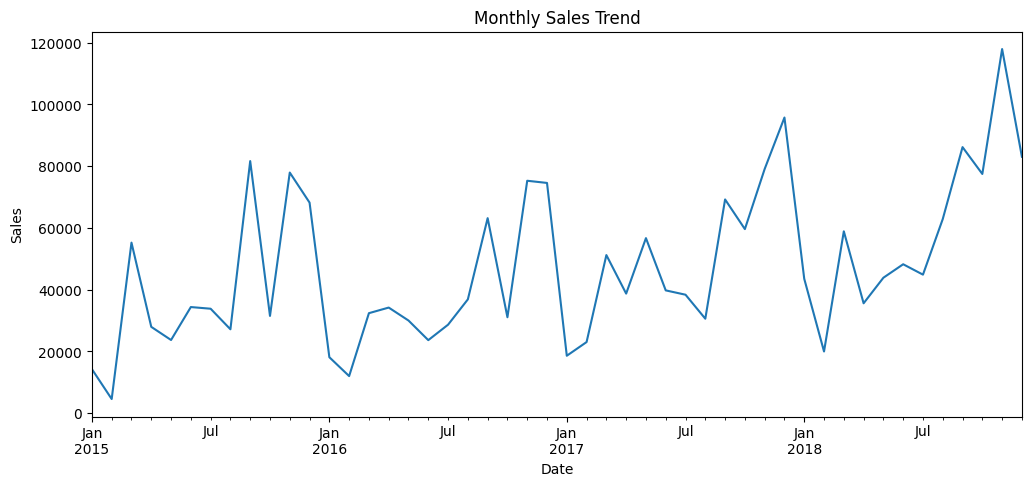

In [18]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [19]:
monthly_sales = monthly_sales.reset_index()
monthly_sales.head()


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [20]:
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Quarter'] = monthly_sales['Order Date'].dt.quarter


In [21]:
monthly_sales.head()


,Order Date,Sales,Year,Month,Quarter
0,2015-01-31,14205.707,2015,1,1
1,2015-02-28,4519.892,2015,2,1
2,2015-03-31,55205.797,2015,3,1
3,2015-04-30,27906.855,2015,4,2
4,2015-05-31,23644.303,2015,5,2


In [22]:
monthly_sales['Lag_1'] = monthly_sales['Sales'].shift(1)


In [23]:
monthly_sales = monthly_sales.dropna()


In [24]:
monthly_sales.head()


,Order Date,Sales,Year,Month,Quarter,Lag_1
1,2015-02-28,4519.8920,2015,2,1,14205.707
2,2015-03-31,55205.7970,2015,3,1,4519.892
3,2015-04-30,27906.8550,2015,4,2,55205.797
4,2015-05-31,23644.3030,2015,5,2,27906.855
5,2015-06-30,34322.9356,2015,6,2,23644.303


In [25]:
X = monthly_sales[['Year', 'Month', 'Quarter', 'Lag_1']]
y = monthly_sales['Sales']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
predictions = model.predict(X_test)


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 11171.606637607863
RMSE: 16156.678117012952


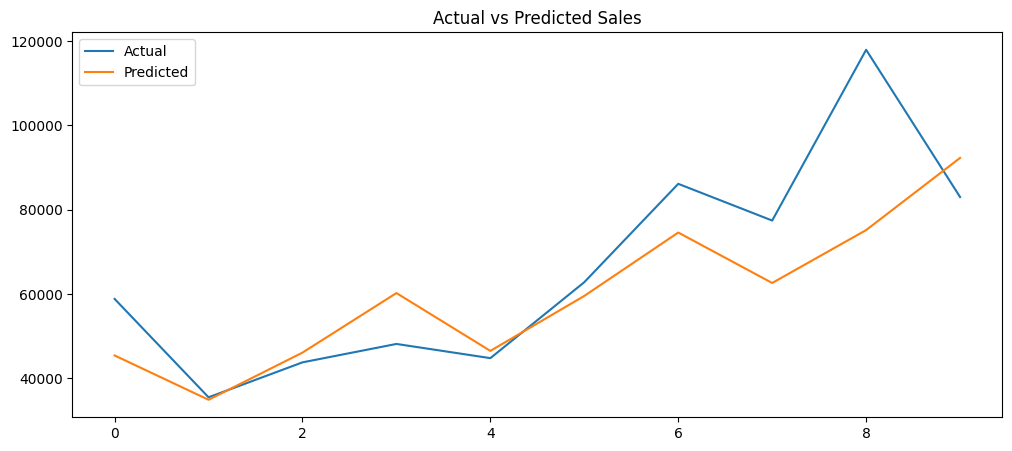

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


In [32]:
monthly_sales.tail()


,Order Date,Sales,Year,Month,Quarter,Lag_1
43,2018-08-31,62837.8480,2018,8,3,44825.1040
44,2018-09-30,86152.8880,2018,9,3,62837.8480
45,2018-10-31,77448.1312,2018,10,4,86152.8880
46,2018-11-30,117938.1550,2018,11,4,77448.1312
47,2018-12-31,83030.3888,2018,12,4,117938.1550


In [33]:
last_date = monthly_sales['Order Date'].max()

future_dates = pd.date_range(
    start=last_date,
    periods=7,   # 6 future months + current
    freq='ME'
)[1:]  # remove current month


In [34]:
future_dates


DatetimeIndex(['2019-01-31', '2019-02-28', '2019-03-31', '2019-04-30',
               '2019-05-31', '2019-06-30'],
              dtype='datetime64[us]', freq='ME')

In [35]:
future_df = pd.DataFrame({'Order Date': future_dates})

future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Quarter'] = future_df['Order Date'].dt.quarter


In [36]:
last_sales = monthly_sales['Sales'].iloc[-1]

future_df['Lag_1'] = last_sales


In [37]:
future_predictions = model.predict(
    future_df[['Year', 'Month', 'Quarter', 'Lag_1']]
)

future_df['Forecasted Sales'] = future_predictions

future_df


,Order Date,Year,Month,Quarter,Lag_1,Forecasted Sales
0,2019-01-31,2019,1,1,83030.3888,29793.783787
1,2019-02-28,2019,2,1,83030.3888,43144.477870
2,2019-03-31,2019,3,1,83030.3888,56495.171953
3,2019-04-30,2019,4,2,83030.3888,42373.777887
4,2019-05-31,2019,5,2,83030.3888,55724.471970
5,2019-06-30,2019,6,2,83030.3888,69075.166053


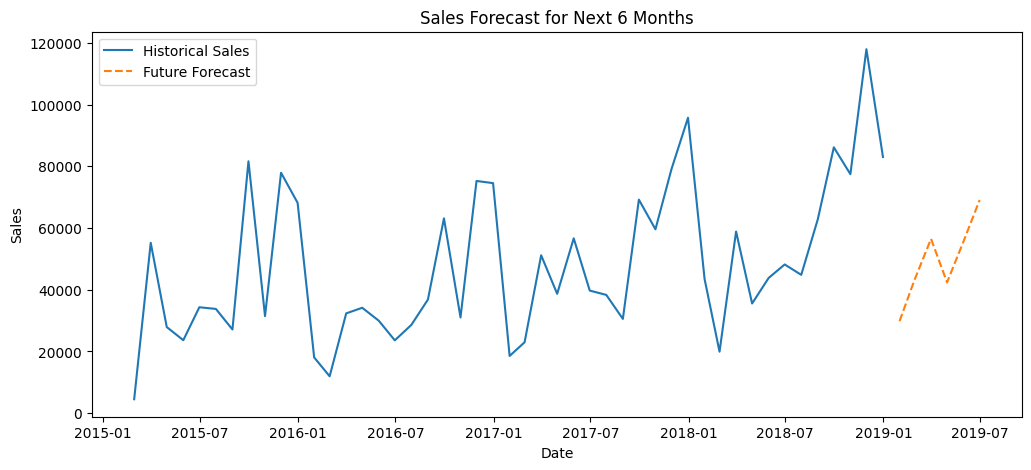

<Figure size 640x480 with 0 Axes>

In [45]:
plt.figure(figsize=(12,5))

# Plot historical data
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label="Historical Sales")

# Plot forecast
plt.plot(future_df['Order Date'], future_df['Forecasted Sales'], 
         label="Future Forecast", linestyle='--')

plt.legend()
plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
plt.savefig("forecast_plot.png")

## 📊 Business Forecast Insights

Based on the forecasting model results, sales are expected to show a gradual upward trend over the next 6 months.

### 🔍 Key Observations
- Sales demonstrate seasonal fluctuations with identifiable peak months.
- The overall trend indicates steady growth.
- Forecast values closely follow historical patterns.

### 🏢 Business Implications
- Inventory levels should be increased ahead of projected peak months.
- Staffing and operational planning can be adjusted according to expected demand.
- Marketing campaigns can be scheduled strategically during high-growth periods.
- Financial planning and cash flow management become more predictable.

### 📈 Strategic Value
Sales forecasting enables data-driven decision-making, reduces overstock risk, and improves profitability through proactive planning.


In [44]:
plt.savefig("forecast_plot.png")


<Figure size 640x480 with 0 Axes>